<a href="https://colab.research.google.com/github/ryanclaytoncollins-design/ITAI_ML_FirstRepo_Ryan/blob/main/Lab4RyanCollins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is a library built on top of Matplotlib that makes creating beautiful plots easier.

# Load the dataset directly from a URL
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("--- First 5 Rows ---")
print(df.head())

print("--- Basic Info ---")
# .info() is a great first command. It tells us the column names, how many non-null values are in each column, and their data types.
# Notice that 'Age' and 'Cabin' have missing values!
df.info()

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

In [ ]:
# Get summary statistics for numerical columns
print("--- Descriptive Statistics ---")
print(df.describe())

print("--- Key Insights from Statistics ---")
print(f"The average age of a passenger was {df['Age'].mean():.1f} years.")
print(f"The overall survival rate was {df['Survived'].mean():.1%}.")
print(f"Fares ranged from ${df['Fare'].min()} to a whopping ${df['Fare'].max()}.")

--- Descriptive Statistics ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
--- Key Insights from Statistics ---
The average a

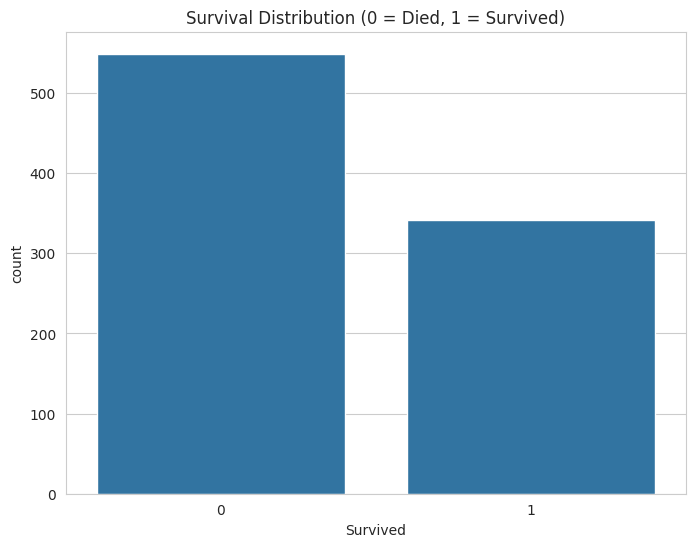

Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.


In [ ]:
sns.set_style('whitegrid') # Sets a nice visual style for our plots
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.show()

print("Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.")

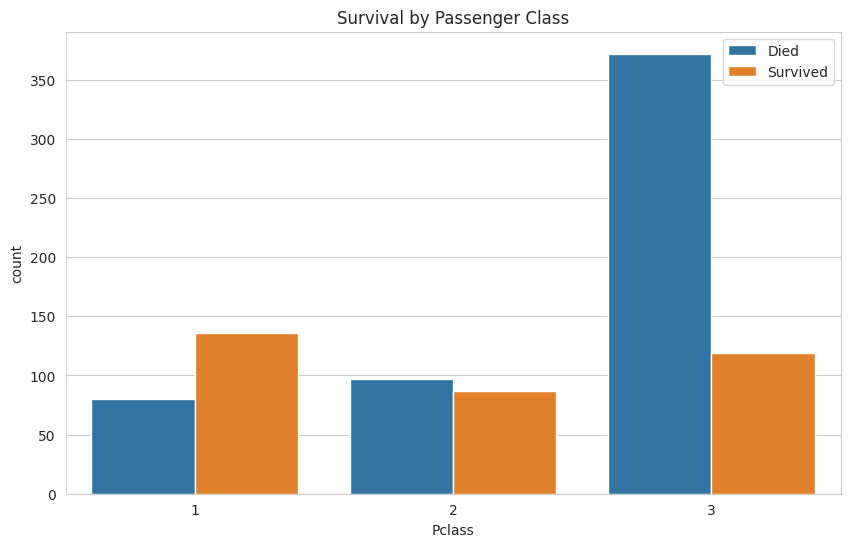

Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.legend(['Died', 'Survived'])
plt.show()

print("Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.")

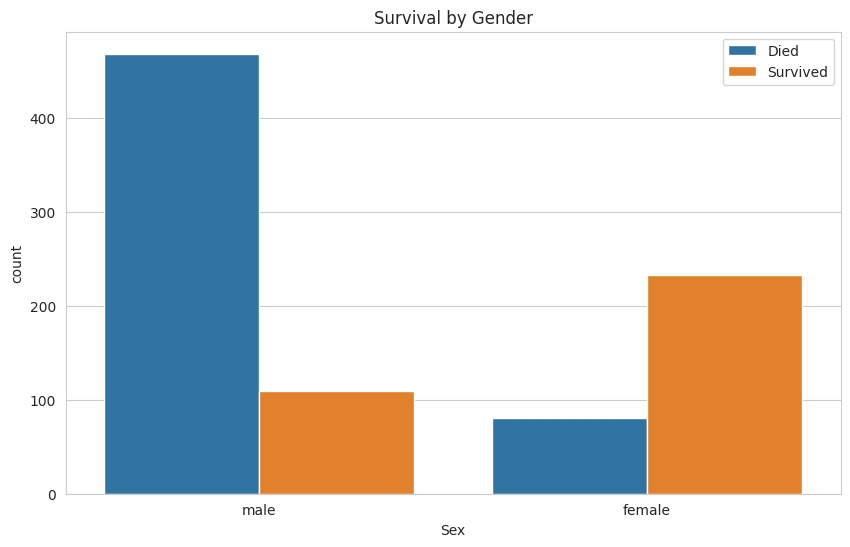

Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.legend(['Died', 'Survived'])
plt.show()

print("Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.")

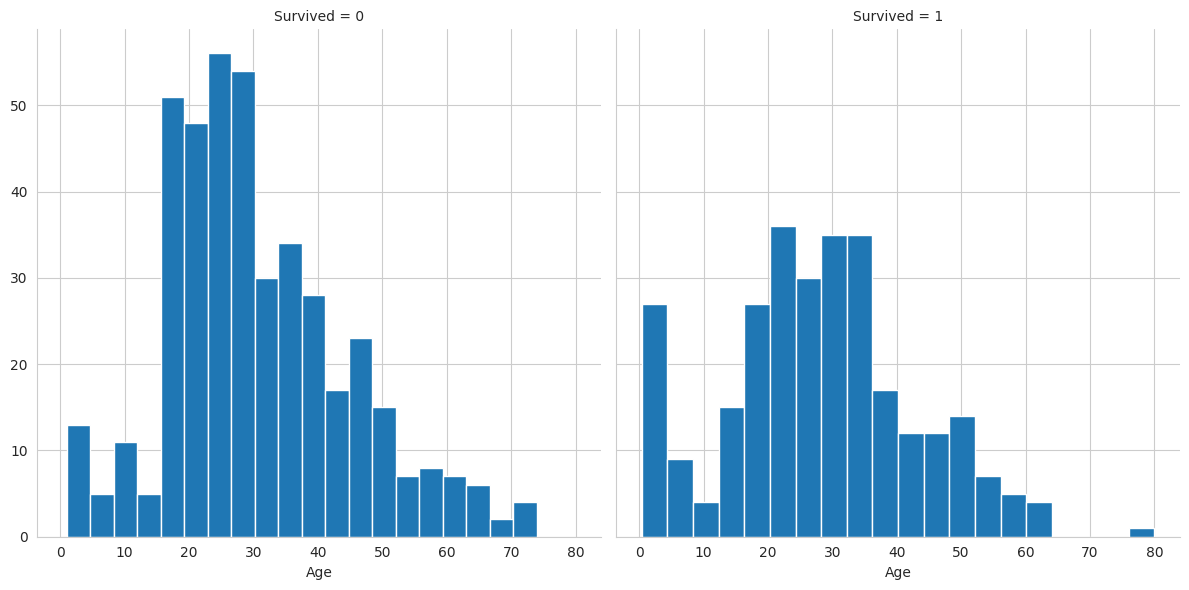

Insight: The age distribution for those who did not survive is centered around the 20-40 age range. For those who survived, there is a noticeable spike for young children. This supports the 'children' part of the mantra.


In [ ]:
# A FacetGrid allows us to create multiple plots side-by-side to compare distributions.
# Here, we create one histogram for passengers who died (col='Survived'=0) and one for those who survived (col='Survived'=1).
g = sns.FacetGrid(df, col='Survived', height=6)
g.map(plt.hist, 'Age', bins=20)
plt.show()

print("Insight: The age distribution for those who did not survive is centered around the 20-40 age range. For those who survived, there is a noticeable spike for young children. This supports the 'children' part of the mantra.")

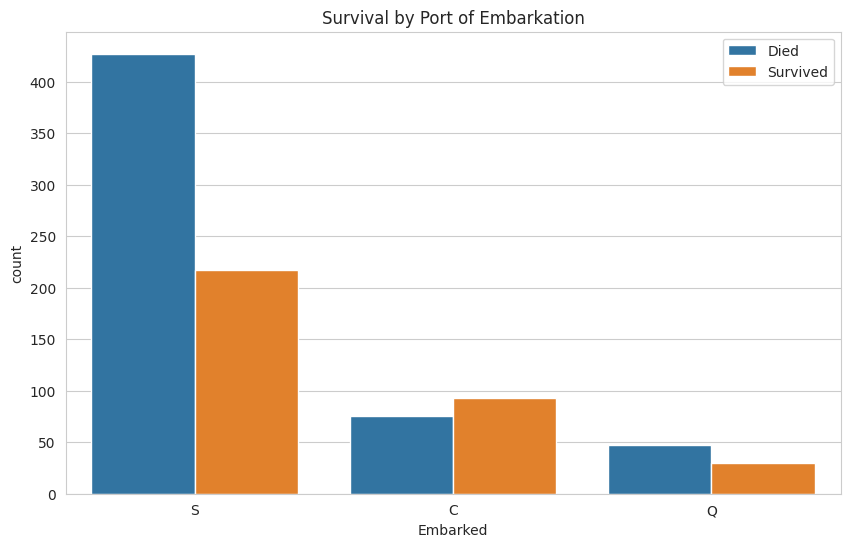

Insight: Passengers who boarded at Cherbourg (C) had a higher survival rate compared to those from Queenstown (Q) and Southampton (S). This may be related to the higher proportion of 1st class passengers boarding at Cherbourg.


In [ ]:
# --- ENTER YOUR CODE HERE ---
plt.figure(figsize=(10, 6))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Port of Embarkation')
plt.legend(['Died', 'Survived'])
plt.show()

print("Insight: Passengers who boarded at Cherbourg (C) had a higher survival rate compared to those from Queenstown (Q) and Southampton (S). This may be related to the higher proportion of 1st class passengers boarding at Cherbourg.")

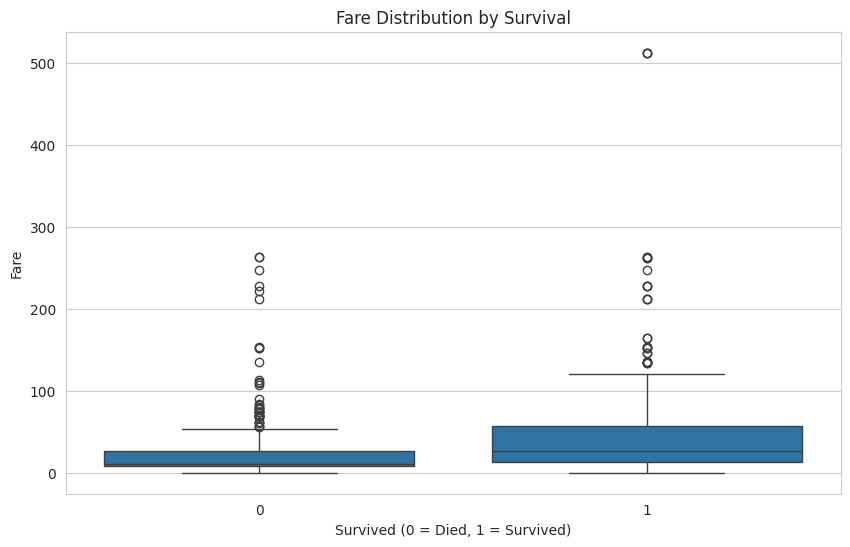

Insight: Passengers who survived generally paid higher fares. The median fare for survivors is noticeably higher, and there are many more high-fare outliers among survivors. This aligns with the earlier finding that 1st class passengers had better survival odds.


In [ ]:
# --- ENTER YOUR CODE HERE ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0 = Died, 1 = Survived)')
plt.ylabel('Fare')
plt.show()

print("Insight: Passengers who survived generally paid higher fares. The median fare for survivors is noticeably higher, and there are many more high-fare outliers among survivors. This aligns with the earlier finding that 1st class passengers had better survival odds.")

## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

1.  **What is the primary goal of Exploratory Data Analysis (EDA)?**
The primary goal of Exploratory Data Analysis is to fully understand the data before attemtping to build a machine lernaing model with the data. EDA helps find relationships in the data sets as well as find possible problems, patterns, missing data or possible trends that may appear in the data. This is used to make sure the machine learning model is successful.
2.  **Based on the plots in this lab, what kind of person had the best chance of surviving the Titanic?** The most common type of person to survive based on the data sets would be a woman in first class between the ages of 15-30.
3.  **Why is it important to visualize data instead of just looking at summary statistics?** What can a plot show you that a number like 'mean' or 'count' can't? plots and other visual data can help you to notice patterns or find outliers easily. You could even find things like none of the data near the average and instead having two big clusters on either side.

**[ENTER YOUR ANSWERS HERE]**